In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import numpy as np

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ==============================================================================
# CELL 2: DOWNLOAD AND PREPARE DATASET
# ==============================================================================
# --- Download from Kaggle ---
import kagglehub
path = kagglehub.dataset_download("mdriyadhossain/ai-medleafx")

print("Path to dataset files:", path)

100%|██████████| 671M/671M [00:07<00:00, 88.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mdriyadhossain/ai-medleafx/versions/1


In [3]:
import os
dataset_path = "/root/.cache/kagglehub/datasets/mdriyadhossain/ai-medleafx/versions/1"
print("Verified path to dataset files:", dataset_path)

# Assuming the structure is dataset_path -> 'Resized Image' -> Plant Type -> Disease/Health Status -> Images
resized_image_base_path = os.path.join(dataset_path, 'Resized Image')

all_class_dirs = []
class_counts = {}

print("\nExploring dataset structure and counting images:")

try:
    # List plant type directories within 'Resized Image'
    plant_type_dirs = [d for d in os.listdir(resized_image_base_path) if os.path.isdir(os.path.join(resized_image_base_path, d))]
    print(f"\nFound {len(plant_type_dirs)} plant types:", plant_type_dirs)

    if not plant_type_dirs:
        print("No plant type directories found within 'Resized Image'. Cannot proceed with expected structure.")
    else:
        # Iterate through each plant type directory
        for plant_type_dir in plant_type_dirs:
            plant_type_path = os.path.join(resized_image_base_path, plant_type_dir)

            # List disease/health status directories within each plant type
            status_dirs = [d for d in os.listdir(plant_type_path) if os.path.isdir(os.path.join(plant_type_path, d))]
            print(f"\nExploring '{plant_type_dir}': Found {len(status_dirs)} status categories:", status_dirs)

            if not status_dirs:
                print(f"No status directories found within '{plant_type_dir}'.")
            else:
                # Iterate through each status directory (these are the actual classes)
                for status_dir in status_dirs:
                    class_name = f"{plant_type_dir}_{status_dir}" # Combine plant type and status for a unique class name
                    class_path = os.path.join(plant_type_path, status_dir)
                    all_class_dirs.append(class_name)

                    # Count image files in the class directory
                    image_files_in_class = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg','.JPG'))]
                    class_counts[class_name] = len(image_files_in_class)
                    print(f"- {class_name}: {class_counts[class_name]} images")

        # Determine the total number of classes
        num_classes = len(all_class_dirs)
        print(f"\nTotal number of classes: {num_classes}")

        # Display class distribution summary
        print("\nClass distribution:")
        for class_name, count in class_counts.items():
            print(f"- {class_name}: {count}")

        # Calculate total number of images
        total_images = sum(class_counts.values())
        print(f"\nTotal number of images: {total_images}")

except FileNotFoundError:
    print(f"Error: The directory '{resized_image_base_path}' was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


print("\nDataset exploration and counting complete.")

Verified path to dataset files: /root/.cache/kagglehub/datasets/mdriyadhossain/ai-medleafx/versions/1

Exploring dataset structure and counting images:

Found 4 plant types: ['Neem', 'HariTaki', 'Sojina', 'Camphor']

Exploring 'Neem': Found 4 status categories: ['Healthy Leaf', 'Shot Hole Leaf', 'Yellow Leaf', 'Powdery Mildew']
- Neem_Healthy Leaf: 1021 images
- Neem_Shot Hole Leaf: 834 images
- Neem_Yellow Leaf: 854 images
- Neem_Powdery Mildew: 854 images

Exploring 'HariTaki': Found 3 status categories: ['Shot Hole', 'Bacterial Spot', 'Healthy Leaf']
- HariTaki_Shot Hole: 802 images
- HariTaki_Bacterial Spot: 803 images
- HariTaki_Healthy Leaf: 816 images

Exploring 'Sojina': Found 3 status categories: ['Bacterial Spot', 'Healthy Leaf', 'Yellow Leaf']
- Sojina_Bacterial Spot: 804 images
- Sojina_Healthy Leaf: 860 images
- Sojina_Yellow Leaf: 814 images

Exploring 'Camphor': Found 3 status categories: ['Shot Hole', 'Bacterial Spot', 'Healthy Leaf']
- Camphor_Shot Hole: 795 images
- C

In [4]:
# ==============================================================================
# CELL 3: DATA SPLITTING
# ==============================================================================
import os, shutil
import pandas as pd
from sklearn.model_selection import train_test_split

# Define paths
original_base_dir = os.path.join(dataset_path, 'Resized Image')
new_base_dir = '/content/data'

# Collect image paths and labels
data = []
for plant in os.listdir(original_base_dir):
    for status in os.listdir(os.path.join(original_base_dir, plant)):
        label = f"{plant}_{status}"
        path = os.path.join(original_base_dir, plant, status)
        for fname in os.listdir(path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png','.JPG')):
                data.append({'path': os.path.join(path, fname), 'label': label})

df = pd.DataFrame(data)

# Split dataset: 80% train, 10% val, 10% test
train_val, test = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)
train, val = train_test_split(train_val, test_size=0.1, stratify=train_val['label'], random_state=42)
# Output summary
total = len(df)
print(f"\n Dataset Split Summary:")
print(f"- Total images: {total}")
print(f"- Training set : {len(train):5d} images ({len(train)/total:.1%})")
print(f"- Validation set: {len(val):5d} images ({len(val)/total:.1%})")
print(f"- Test set     : {len(test):5d} images ({len(test)/total:.1%})\n")

# Copy files
for split_df, split in zip([train, val, test], ['train', 'val', 'test']):
    print(f" Copying {split} files...")
    for _, row in split_df.iterrows():
        dst_dir = os.path.join(new_base_dir, split, row['label'])
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy(row['path'], os.path.join(dst_dir, os.path.basename(row['path'])))
    print(f" {split.capitalize()} files copied: {len(split_df)}")

print("\n All files have been split and copied successfully.")



 Dataset Split Summary:
- Total images: 10858
- Training set :  8794 images (81.0%)
- Validation set:   978 images (9.0%)
- Test set     :  1086 images (10.0%)

 Copying train files...
 Train files copied: 8794
 Copying val files...
 Val files copied: 978
 Copying test files...
 Test files copied: 1086

 All files have been split and copied successfully.


In [5]:
import random
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [6]:
IMG_SIZE = 224

# Enhanced augmentation pipeline - more aggressive for better learned representations
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.08, 1.0), ratio=(0.75, 1.33)),  # Wider scale range
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),  # Added vertical flip for plant leaves
    transforms.RandomRotation(30),  # Increased rotation
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2),  # Stronger color jitter
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))], p=0.5),  # Gaussian blur
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class SimCLRTransforms:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return self.transform(x), self.transform(x)

# ==============================================================================
# CELL X: DATA LOADERS
# ==============================================================================
from torchvision.datasets import ImageFolder

BATCH_SIZE = 32

# Standard transformations for validation and test sets (less aggressive augmentation than train_tfms)
# These will be applied within SimCLRTransforms for validation and test views.
# The idea is to still have two views for NTXentLoss calculation during evaluation,
# but using a more 'standard' augmentation pipeline for consistency in evaluation.
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets with SimCLRTransforms for all splits,
# as the training loop and feature extraction functions expect (img1, img2) structure.
train_dataset = ImageFolder(os.path.join(new_base_dir, 'train'), transform=SimCLRTransforms(train_tfms))
val_dataset = ImageFolder(os.path.join(new_base_dir, 'val'), transform=SimCLRTransforms(eval_transform))
test_dataset = ImageFolder(os.path.join(new_base_dir, 'test'), transform=SimCLRTransforms(eval_transform))

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, drop_last=False)


print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Train loader batches: {len(train_loader)}")
print(f"Validation loader batches: {len(val_loader)}")
print(f"Test loader batches: {len(test_loader)}")

Train dataset size: 8794
Validation dataset size: 978
Test dataset size: 1086
Train loader batches: 274
Validation loader batches: 31
Test loader batches: 34


In [7]:
class ImprovedResNet50SimCLR(nn.Module):
    def __init__(self, out_dim=256):  # Increased from 128 to 256
        super().__init__()
        base_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Remove final classification layer
        base_model.fc = nn.Identity()
        self.encoder = base_model

        # Improved projection head with 3 layers (SimCLR v2 style)
        self.projector = nn.Sequential(
            nn.Linear(2048, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, out_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        z = self.projector(features)
        return z

In [8]:
class ImprovedNTXentLoss(nn.Module):
    def __init__(self, temperature=0.07):  # Lower temperature for harder negatives
        super().__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, z1, z2):
        batch_size = z1.size(0)

        # L2 normalization
        z1 = nn.functional.normalize(z1, dim=1)
        z2 = nn.functional.normalize(z2, dim=1)

        # Concatenate
        z = torch.cat([z1, z2], dim=0)  # (2N, D)

        # Compute similarity matrix
        sim_matrix = torch.matmul(z, z.T) / self.temperature

        # Create mask to remove self-similarity
        mask = torch.eye(2 * batch_size, dtype=torch.bool).to(z.device)
        sim_matrix = sim_matrix.masked_fill(mask, float('-inf')) # Changed -1e9 to float('-inf')

        # Positive pairs indices
        pos_labels = torch.cat([
            torch.arange(batch_size, 2 * batch_size),
            torch.arange(0, batch_size)
        ]).to(z.device)

        # Calculate loss and accuracy
        loss = self.criterion(sim_matrix, pos_labels)
        preds = torch.argmax(sim_matrix, dim=1)
        acc = (preds == pos_labels).float().mean().item()

        return loss, acc

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize model with larger projection dimension
model = ImprovedResNet50SimCLR(out_dim=256).to(device)

# Use lower temperature for harder negatives
criterion = ImprovedNTXentLoss(temperature=0.07)

# Optimized optimizer settings
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,  # Slightly higher learning rate
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

# Training parameters
EPOCHS = 10
WARMUP_EPOCHS = 10

# Cosine annealing with warmup
def warmup_lr_scheduler(epoch, warmup_epochs=WARMUP_EPOCHS):
    if epoch < warmup_epochs:
        return float(epoch) / float(max(1, warmup_epochs))
    return 1.0

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)


Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


In [10]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()
accumulation_steps = 2  # Effective batch size = 32 * 2 = 64

def train_one_epoch_improved():
    model.train()
    running_loss, running_acc = 0.0, 0.0
    optimizer.zero_grad()

    for i, ((x1, x2), _) in enumerate(tqdm(train_loader, desc="Training", leave=False)):
        x1, x2 = x1.to(device), x2.to(device)

        # Mixed precision training
        with autocast():
            z1, z2 = model(x1), model(x2)
            loss, acc = criterion(z1, z2)
            loss = loss / accumulation_steps

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()

        # Gradient accumulation
        if (i + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += loss.item() * accumulation_steps * x1.size(0)
        running_acc += acc * x1.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_acc / len(train_loader.dataset)
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate_improved(loader):
    model.eval()
    running_loss, running_acc = 0.0, 0.0

    for (x1, x2), _ in tqdm(loader, desc="Evaluating", leave=False):
        x1, x2 = x1.to(device), x2.to(device)

        with autocast():
            z1, z2 = model(x1), model(x2)
            loss, acc = criterion(z1, z2)

        running_loss += loss.item() * x1.size(0)
        running_acc += acc * x1.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_acc / len(loader.dataset)
    return epoch_loss, epoch_acc

/tmp/ipython-input-2333225885.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [11]:
# ======================
# CONFIG
# ======================
EPOCHS = 1          # <-- change this anytime
WARMUP_EPOCHS = 10
patience = 15

# ======================
# INITIALIZATION
# ======================
best_loss = float('inf')
patience_counter = 0

train_losses, val_losses, train_accs, val_accs = [], [], [], []

print(f"Starting improved training for {EPOCHS} epochs...")
training_start = time.time()

for epoch in range(1, EPOCHS + 1):
    # Learning rate warmup
    if epoch <= WARMUP_EPOCHS:
        for param_group in optimizer.param_groups:
            param_group['lr'] = 3e-4 * warmup_lr_scheduler(epoch)

    tr_loss, tr_acc = train_one_epoch_improved()
    va_loss, va_acc = evaluate_improved(val_loader)

    if epoch > WARMUP_EPOCHS:
        scheduler.step()

    # Track metrics
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_accs.append(tr_acc)
    val_accs.append(va_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:02d} | LR: {current_lr:.6f} | "
          f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc*100:.2f}% | "
          f"Val Loss: {va_loss:.4f} | Val Acc: {va_acc*100:.2f}%")

    # Early stopping
    if va_loss < best_loss:
        best_loss = va_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch} epochs")
            break

training_time = time.time() - training_start
print(f"\nTraining Complete! Best Val Loss: {best_loss:.4f}")
print(f"Total Time: {training_time:.2f}s ({training_time/60:.2f} min)")


Starting improved training for 1 epochs...


Training:   0%|          | 0/274 [00:00<?, ?it/s]/tmp/ipython-input-2333225885.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]/tmp/ipython-input-2333225885.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
                                                           

Epoch 01 | LR: 0.000030 | Train Loss: 2.0834 | Train Acc: 44.43% | Val Loss: 0.3220 | Val Acc: 100.00%

Training Complete! Best Val Loss: 0.3220
Total Time: 525.99s (8.77 min)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


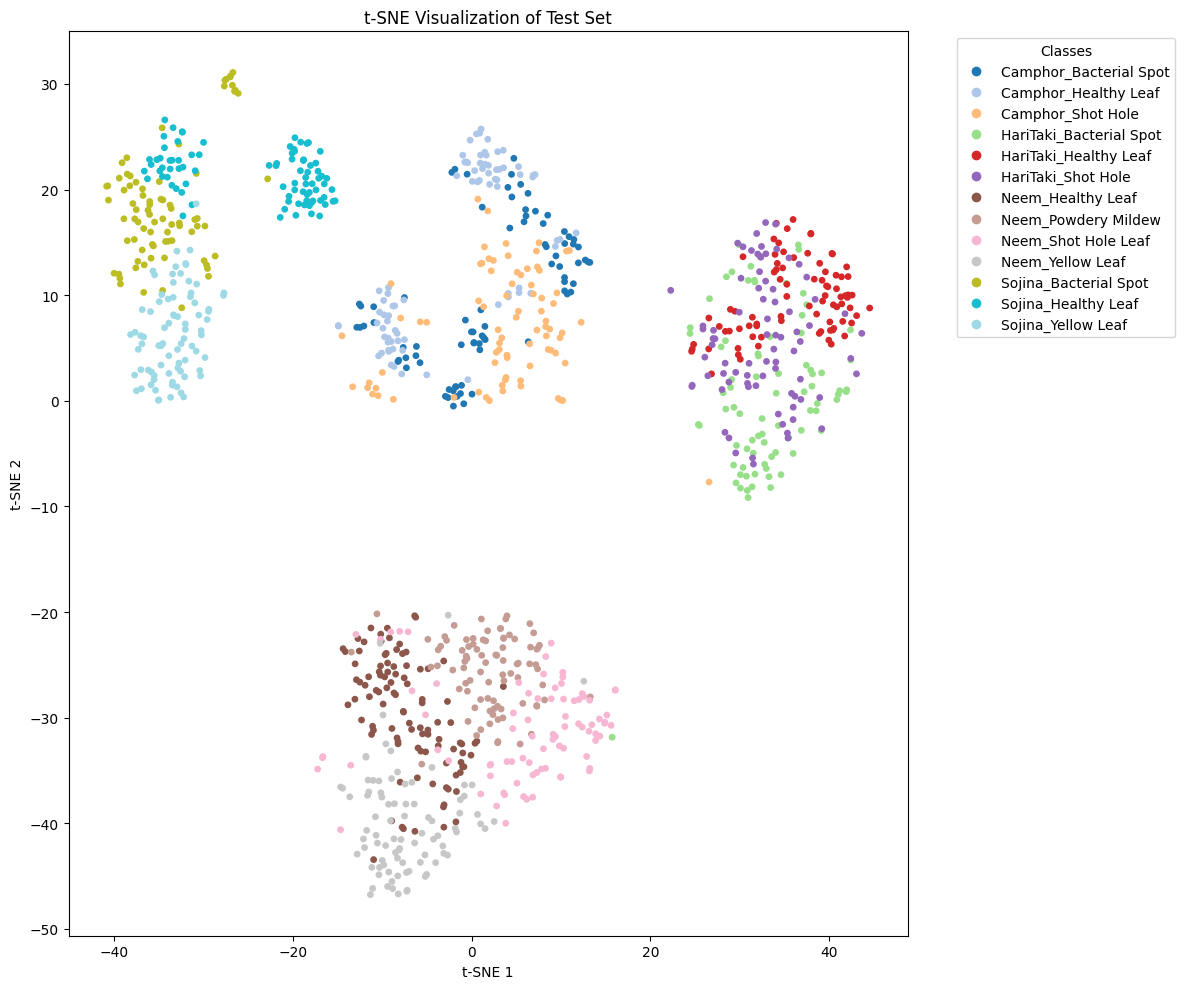

In [12]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# =========================================
# 1️⃣ Feature Extraction Function
# =========================================
def extract_features(model, loader, device='cuda'):
    model.eval()
    all_features = []
    all_labels = []
    with torch.no_grad():
        for (img1, img2), labels in loader: # Unpack the views
            # For feature extraction, we typically only need one view
            img1 = img1.to(device)
            feats = model.encoder(img1)  # Use model.encoder for features
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())
    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_features, all_labels

# =========================================
# 2️⃣ Extract Features from Test Loader
# =========================================
# Make sure to define 'device' if not already global
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_test, y_test = extract_features(model, test_loader, device=device)

# =========================================
# 3️⃣ t-SNE Dimensionality Reduction
# =========================================
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_test_tsne = tsne.fit_transform(X_test)

# =========================================
# 4️⃣ Map integer labels to class names
# =========================================
# Retrieve class_to_idx from one of the datasets
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}  # invert dictionary
y_test_names = [idx_to_class[i] for i in y_test]

# =========================================
# 5️⃣ Plot t-SNE with class names
# =========================================
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_test, cmap='tab20', s=15)

# Create legend with actual class names
handles, _ = scatter.legend_elements()
unique_labels = np.unique(y_test)
plt.legend(handles, [idx_to_class[i] for i in unique_labels], title="Classes",
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("t-SNE Visualization of Test Set")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import torch
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


# ============================================================================
# 1. FEATURE EXTRACTION
# ============================================================================
def extract_features(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for (images, labels) in tqdm(dataloader, desc="Extracting features"):
            # The dataloader for SimCLR returns (x1, x2) as images.
            # For feature extraction, we only need one view.
            images = images[0].to(device) # Use only the first view and move to device
            # The model's encoder contains the feature extractor
            feats = model.encoder(images)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_labels   = np.concatenate(all_labels, axis=0)
    return all_features, all_labels


# ============================================================================
# 2. EXTRACT TRAIN & TEST FEATURES
# ============================================================================
train_X, train_y = extract_features(model, train_loader, device)
test_X,  test_y  = extract_features(model, test_loader, device)


# ============================================================================
# 3. STANDARDIZE FEATURES
# ============================================================================
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
test_X  = scaler.transform(test_X)


# ============================================================================
# 4. PCA DIMENSIONALITY REDUCTION
# ============================================================================
pca = PCA(n_components=512, random_state=42)
train_X = pca.fit_transform(train_X)
test_X  = pca.transform(test_X)


# ============================================================================
# 5. DEFINE CLASSIFIERS (MLP + SVM + DT + RF)
# ============================================================================
classifiers = {

    "MLP": MLPClassifier(
        hidden_layer_sizes=(1024, 512, 256),
        activation='relu',
        solver='adam',
        learning_rate_init=0.00001,
        max_iter=1400,
        random_state=42,
        verbose=True
    ),

    "SVM (RBF)": SVC(
        kernel="rbf",
        C=10.0,
        gamma="scale",
        probability=True,   # 🔴 REQUIRED FOR ROC
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion="gini",
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )
}


# ============================================================================
# 6. TRAIN & EVALUATE ALL MODELS
# ============================================================================
results = {}

for name, clf in classifiers.items():
    print(f"\nTraining {name}...")
    clf.fit(train_X, train_y)

    preds = clf.predict(test_X)
    acc = accuracy_score(test_y, preds)

    results[name] = acc
    print(f"{name} Test Accuracy: {acc * 100:.2f}%")


# ============================================================================
# 7. FINAL SUMMARY
# ============================================================================
print("\n================ FINAL COMPARISON ================")
for name, acc in results.items():
    print(f"{name}: {acc * 100:.2f}%")

Extracting features: 100%|██████████| 34/34 [00:09<00:00,  3.62it/s]



Training MLP...
Iteration 1, loss = 2.66855184
Iteration 2, loss = 2.18724767
Iteration 3, loss = 1.83781846
Iteration 4, loss = 1.56639754
Iteration 5, loss = 1.35910857
Iteration 6, loss = 1.20150418
Iteration 7, loss = 1.08169276
Iteration 8, loss = 0.98889945
Iteration 9, loss = 0.91658149
Iteration 10, loss = 0.85774001
Iteration 11, loss = 0.80914179
Iteration 12, loss = 0.76816661
Iteration 13, loss = 0.73278361
Iteration 14, loss = 0.70198797
Iteration 15, loss = 0.67430791
Iteration 16, loss = 0.65001762
Iteration 17, loss = 0.62771251
Iteration 18, loss = 0.60746793
Iteration 19, loss = 0.58871688
Iteration 20, loss = 0.57126184
Iteration 21, loss = 0.55524467
Iteration 22, loss = 0.53951787
Iteration 23, loss = 0.52563420
Iteration 24, loss = 0.51214057
Iteration 25, loss = 0.49910622
Iteration 26, loss = 0.48670077
Iteration 27, loss = 0.47541398
Iteration 28, loss = 0.46338735
Iteration 29, loss = 0.45297337
Iteration 30, loss = 0.44255478
Iteration 31, loss = 0.43283312


Plotting ROC for MLP...


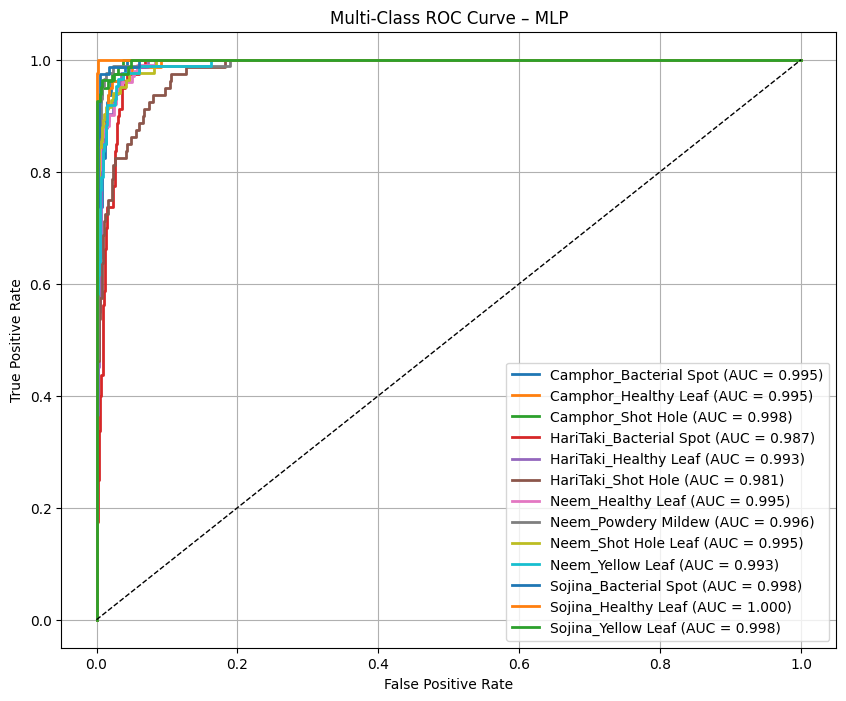

Plotting ROC for SVM (RBF)...


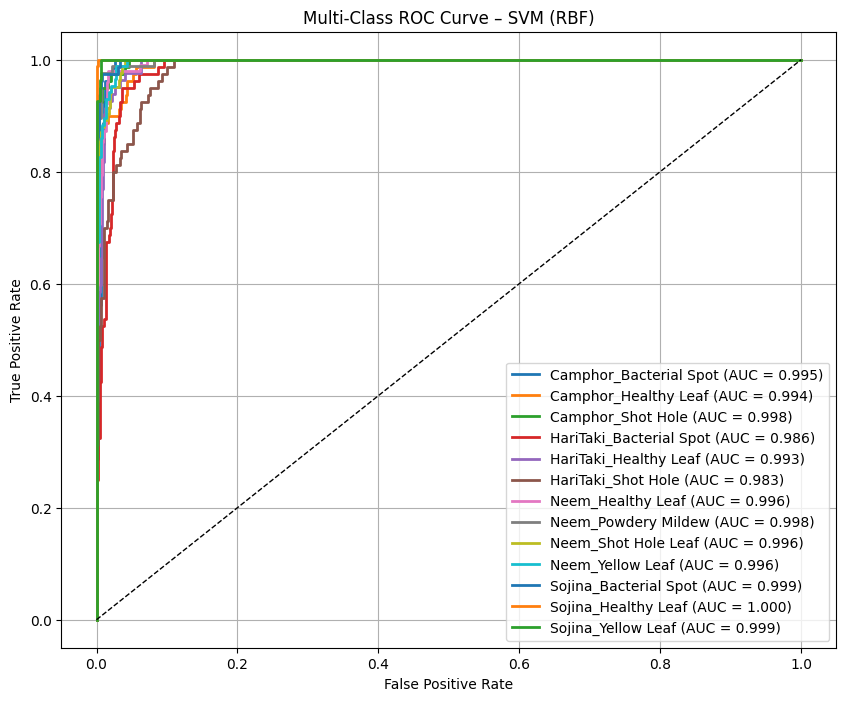

Plotting ROC for Decision Tree...


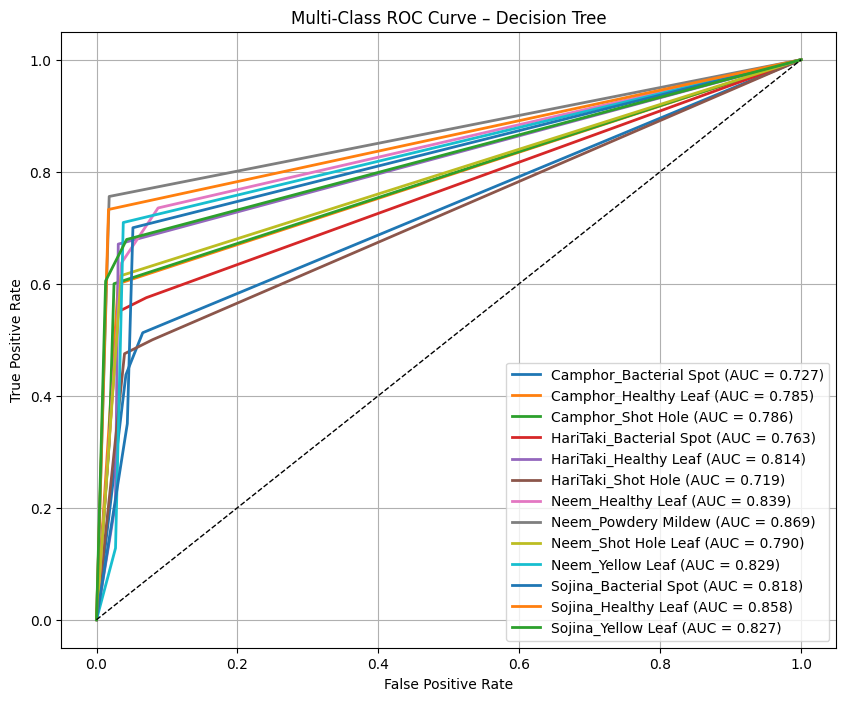

Plotting ROC for Random Forest...


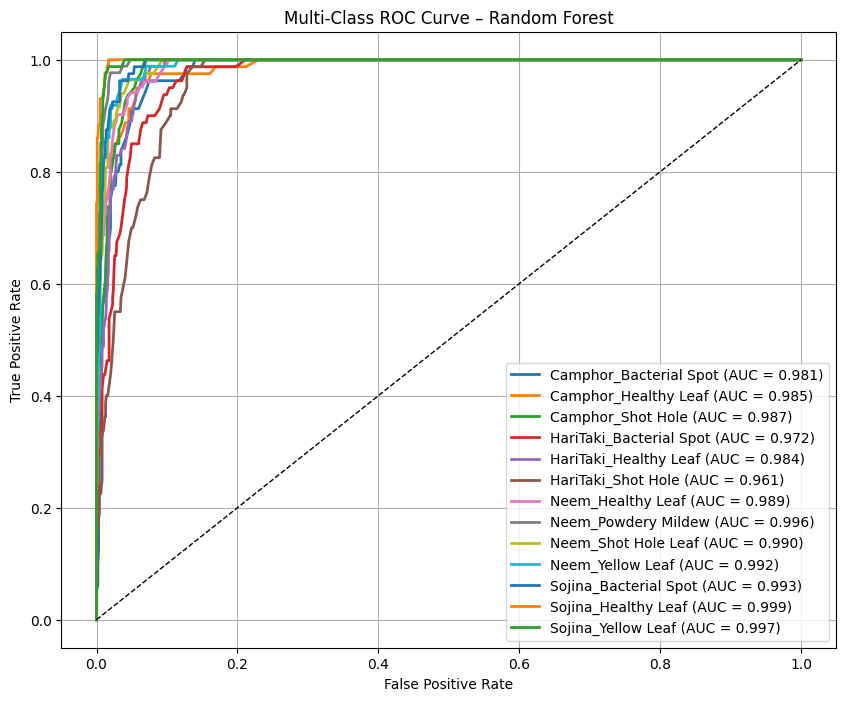

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# ============================================================================
# 7. MULTI-CLASS ROC PLOTTING FUNCTION
# ============================================================================
NUM_CLASSES = len(np.unique(test_y))
y_bin = label_binarize(test_y, classes=list(range(NUM_CLASSES)))

def plot_multiclass_roc(model, model_name, test_X, y_bin, class_names=None):
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(test_X)
    else:
        scores = model.decision_function(test_X)
        if scores.ndim == 1:
            scores = scores.reshape(-1,1)

    plt.figure(figsize=(10,8))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], scores[:, i])
        roc_auc = auc(fpr, tpr)
        label = f"{class_names[i]} (AUC = {roc_auc:.3f})" if class_names else f"Class {i} (AUC = {roc_auc:.3f})"
        plt.plot(fpr, tpr, lw=2, label=label)

    plt.plot([0,1],[0,1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multi-Class ROC Curve – {model_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# ============================================================================
# 8. PLOT ROC FOR ALL MODELS
# ============================================================================
# The 'classifiers' dictionary contains the trained models
for name, model in classifiers.items():
    print(f"Plotting ROC for {name}...")
    # Ensure SVM's predict_proba is callable or handle decision_function
    if name == "SVM (RBF)": # SVM needs probability=True during initialization
        if not hasattr(model, "predict_proba"):
            print(f"Warning: SVM model '{name}' does not have 'predict_proba'. Cannot plot ROC curve for this model.")
            continue
    plot_multiclass_roc(model, name, test_X, y_bin, class_names=list(idx_to_class.values()))


================ MLP =================
✔️ Overall Test Accuracy: 85.91%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          77.50
Camphor_Healthy Leaf            87.50
Camphor_Shot Hole               95.00
HariTaki_Bacterial Spot         83.75
HariTaki_Healthy Leaf           92.68
HariTaki_Shot Hole              50.00
Neem_Healthy Leaf               90.20
Neem_Powdery Mildew             87.21
Neem_Shot Hole Leaf             85.54
Neem_Yellow Leaf                80.23
Sojina_Bacterial Spot           97.50
Sojina_Healthy Leaf             98.84
Sojina_Yellow Leaf              88.89

📄 Classification Report:
                         precision  recall  f1-score   support
Camphor_Bacterial Spot       0.886   0.775     0.827    80.000
Camphor_Healthy Leaf         0.833   0.875     0.854    80.000
Camphor_Shot Hole            0.854   0.950     0.899    80.000
HariTaki_Bacterial Spot      0.705   0.838     0.766    80.000
HariTaki_Healthy Leaf        0.

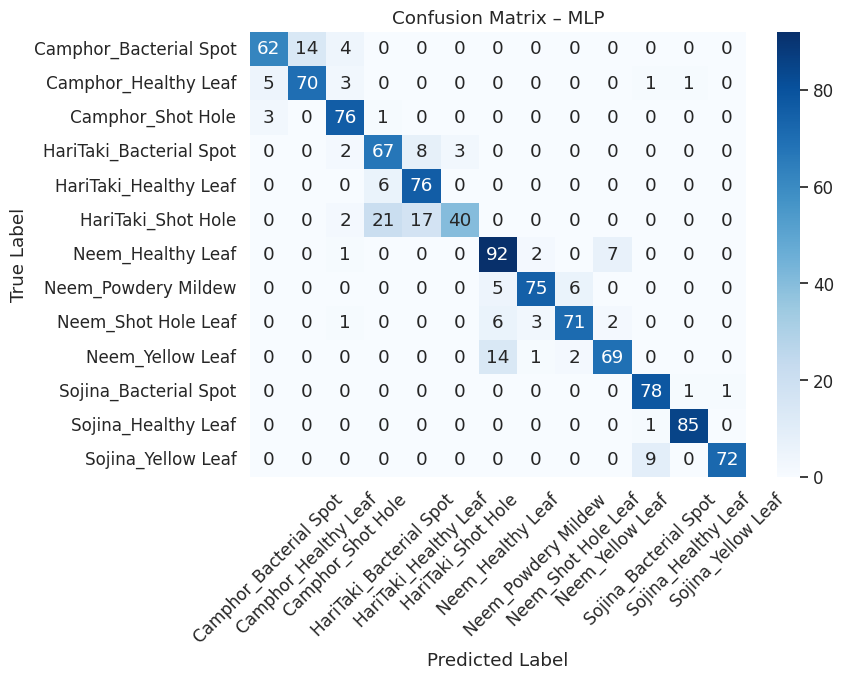


================ SVM (RBF) =================
✔️ Overall Test Accuracy: 87.85%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          83.75
Camphor_Healthy Leaf            87.50
Camphor_Shot Hole               93.75
HariTaki_Bacterial Spot         86.25
HariTaki_Healthy Leaf           92.68
HariTaki_Shot Hole              55.00
Neem_Healthy Leaf               93.14
Neem_Powdery Mildew             87.21
Neem_Shot Hole Leaf             87.95
Neem_Yellow Leaf                90.70
Sojina_Bacterial Spot           97.50
Sojina_Healthy Leaf             96.51
Sojina_Yellow Leaf              87.65

📄 Classification Report:
                         precision  recall  f1-score   support
Camphor_Bacterial Spot       0.870   0.838     0.854    80.000
Camphor_Healthy Leaf         0.854   0.875     0.864    80.000
Camphor_Shot Hole            0.915   0.938     0.926    80.000
HariTaki_Bacterial Spot      0.697   0.862     0.771    80.000
HariTaki_Healthy Leaf    

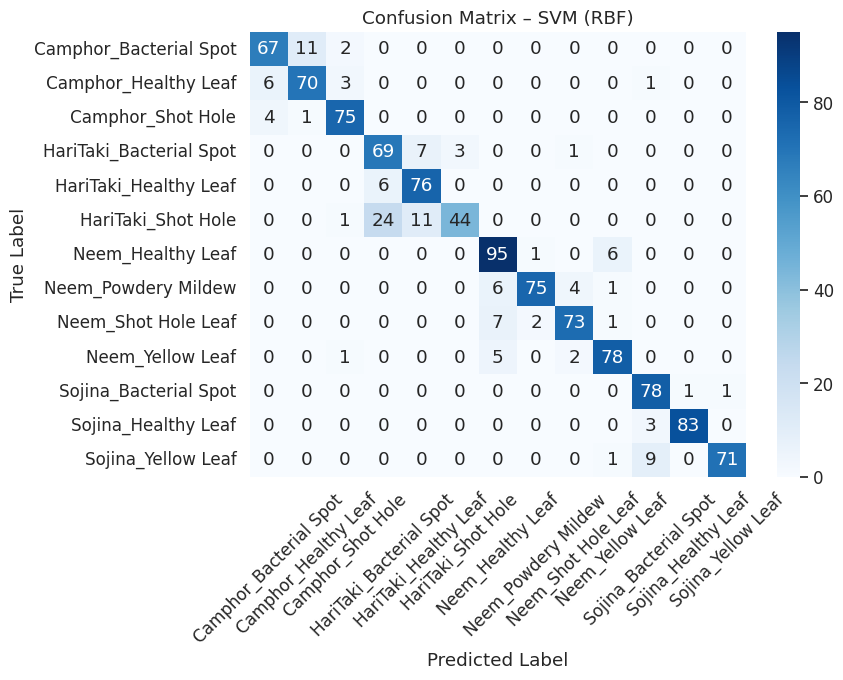


================ Decision Tree =================
✔️ Overall Test Accuracy: 62.43%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          43.75
Camphor_Healthy Leaf            60.00
Camphor_Shot Hole               60.00
HariTaki_Bacterial Spot         55.00
HariTaki_Healthy Leaf           67.07
HariTaki_Shot Hole              47.50
Neem_Healthy Leaf               63.73
Neem_Powdery Mildew             75.58
Neem_Shot Hole Leaf             61.45
Neem_Yellow Leaf                70.93
Sojina_Bacterial Spot           70.00
Sojina_Healthy Leaf             73.26
Sojina_Yellow Leaf              60.49

📄 Classification Report:
                         precision  recall  f1-score   support
Camphor_Bacterial Spot       0.455   0.438     0.446    80.000
Camphor_Healthy Leaf         0.608   0.600     0.604    80.000
Camphor_Shot Hole            0.658   0.600     0.627    80.000
HariTaki_Bacterial Spot      0.587   0.550     0.568    80.000
HariTaki_Healthy Leaf

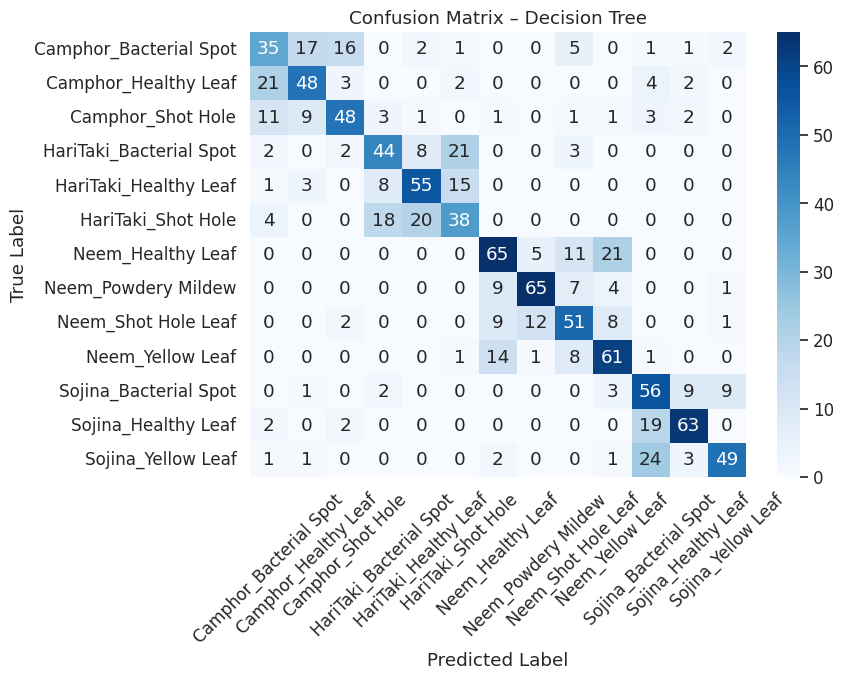


================ Random Forest =================
✔️ Overall Test Accuracy: 80.85%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          65.00
Camphor_Healthy Leaf            82.50
Camphor_Shot Hole               82.50
HariTaki_Bacterial Spot         65.00
HariTaki_Healthy Leaf           89.02
HariTaki_Shot Hole              55.00
Neem_Healthy Leaf               87.25
Neem_Powdery Mildew             81.40
Neem_Shot Hole Leaf             80.72
Neem_Yellow Leaf                90.70
Sojina_Bacterial Spot           93.75
Sojina_Healthy Leaf             89.53
Sojina_Yellow Leaf              85.19

📄 Classification Report:
                         precision  recall  f1-score   support
Camphor_Bacterial Spot       0.743   0.650     0.693    80.000
Camphor_Healthy Leaf         0.733   0.825     0.776    80.000
Camphor_Shot Hole            0.776   0.825     0.800    80.000
HariTaki_Bacterial Spot      0.754   0.650     0.698    80.000
HariTaki_Healthy Leaf

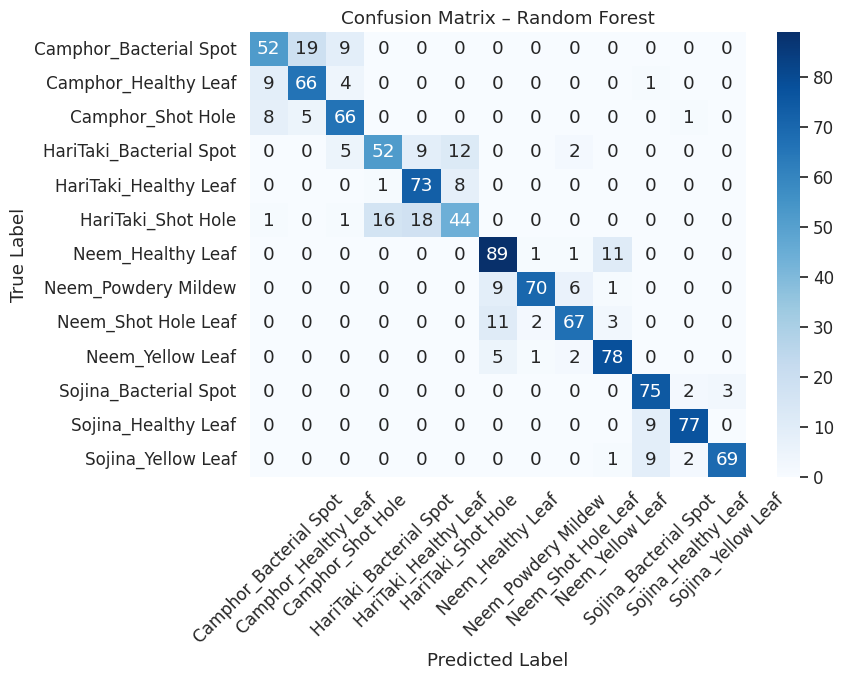


================ FINAL MODEL COMPARISON ================
               Accuracy  Macro Precision  Macro Recall  Macro F1  Accuracy (%)
MLP              0.8591           0.8689        0.8576    0.8557       85.9116
SVM (RBF)        0.8785           0.8864        0.8766    0.8757       87.8453
Decision Tree    0.6243           0.6286        0.6221    0.6228       62.4309
Random Forest    0.8085           0.8103        0.8058    0.8046       80.8471


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# EVALUATION FOR ALL MODELS
# ============================================================
all_results = {}

for model_name, model in classifiers.items():

    print(f"\n================ {model_name} =================")

    # ------------------------------
    # 1️⃣ Predictions
    # ------------------------------
    preds = model.predict(test_X)

    # ------------------------------
    # 2️⃣ Overall Accuracy
    # ------------------------------
    overall_acc = accuracy_score(test_y, preds)
    print(f"✔️ Overall Test Accuracy: {overall_acc * 100:.2f}%")

    # ------------------------------
    # 3️⃣ Per-Class Accuracy
    # ------------------------------
    per_class_acc = {}
    for c in range(NUM_CLASSES):
        idx = np.where(test_y == c)[0]
        class_acc = accuracy_score(test_y[idx], preds[idx])
        class_name = list(class_to_idx.keys())[c]
        per_class_acc[class_name] = class_acc * 100

    df_acc = pd.DataFrame.from_dict(
        per_class_acc, orient='index', columns=['Accuracy (%)']
    ).sort_index()

    print("\n📌 Per-Class Accuracy:")
    print(df_acc.to_string(float_format="%.2f"))

    # ------------------------------
    # 4️⃣ Classification Report
    # ------------------------------
    print("\n📄 Classification Report:")
    report = classification_report(
        test_y,
        preds,
        target_names=list(class_to_idx.keys()),
        digits=3,
        output_dict=True
    )
    df_report = pd.DataFrame(report).T
    print(df_report.round(3))

    # ------------------------------
    # 5️⃣ Macro Metrics
    # ------------------------------
    macro_precision = precision_score(test_y, preds, average="macro")
    macro_recall    = recall_score(test_y, preds, average="macro")
    macro_f1        = f1_score(test_y, preds, average="macro")

    print(f"\n🔹 Macro Precision: {macro_precision:.3f}")
    print(f"🔹 Macro Recall:    {macro_recall:.3f}")
    print(f"🔹 Macro F1-score:  {macro_f1:.3f}")

    # Save summary
    all_results[model_name] = {
        "Accuracy": overall_acc,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1
    }

    # ------------------------------
    # 6️⃣ Confusion Matrix
    # ------------------------------
    cm = confusion_matrix(test_y, preds)

    plt.figure(figsize=(9, 7))
    sns.set(font_scale=1.1)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=list(class_to_idx.keys()),
        yticklabels=list(class_to_idx.keys())
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


df_summary = pd.DataFrame(all_results).T
df_summary["Accuracy (%)"] = df_summary["Accuracy"] * 100

print("\n================ FINAL MODEL COMPARISON ================")
print(df_summary.round(4))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# ------------------------------
# 1. Define labeled fractions
# ------------------------------
fractions = [0.01, 0.05, 0.10, 0.25, 0.50]
n_train = train_X.shape[0]

# Store results
results = {
    "SVM": [],
    "Decision Tree": [],
    "Random Forest": [],
    "MLP": []
}

# ------------------------------
# 2. Loop over fractions
# ------------------------------
for frac in fractions:
    n_samples = max(1, int(n_train * frac))
    np.random.seed(42)
    indices = np.random.choice(n_train, n_samples, replace=False)

    X_subset = train_X[indices]
    y_subset = train_y[indices]

    print(f"\n🔹 Training with {frac*100:.0f}% labeled data ({n_samples} samples)")

    # ---------- SVM ----------
    svm = SVC(kernel="rbf", C=10.0, gamma="scale")
    svm.fit(X_subset, y_subset)
    preds = svm.predict(test_X)
    acc = accuracy_score(test_y, preds)
    results["SVM"].append(acc)
    print(f"SVM Accuracy: {acc*100:.2f}%")

    # ---------- Decision Tree ----------
    dt = DecisionTreeClassifier(
        criterion="gini",
        max_depth=20,
        random_state=42
    )
    dt.fit(X_subset, y_subset)
    preds = dt.predict(test_X)
    acc = accuracy_score(test_y, preds)
    results["Decision Tree"].append(acc)
    print(f"Decision Tree Accuracy: {acc*100:.2f}%")

    # ---------- Random Forest ----------
    rf = RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )
    rf.fit(X_subset, y_subset)
    preds = rf.predict(test_X)
    acc = accuracy_score(test_y, preds)
    results["Random Forest"].append(acc)
    print(f"Random Forest Accuracy: {acc*100:.2f}%")

    # ---------- MLP ----------
    mlp = MLPClassifier(
        hidden_layer_sizes=(1024, 512, 256),
        activation='relu',
        solver='adam',
        learning_rate_init=0.0001,
        max_iter=1000,
        random_state=42
    )
    mlp.fit(X_subset, y_subset)
    preds = mlp.predict(test_X)
    acc = accuracy_score(test_y, preds)
    results["MLP"].append(acc)
    print(f"MLP Accuracy: {acc*100:.2f}%")



🔹 Training with 1% labeled data (87 samples)
SVM Accuracy: 57.92%
Decision Tree Accuracy: 34.25%
Random Forest Accuracy: 29.19%
MLP Accuracy: 53.87%

🔹 Training with 5% labeled data (438 samples)
SVM Accuracy: 78.08%
Decision Tree Accuracy: 46.69%
Random Forest Accuracy: 67.86%
MLP Accuracy: 76.80%

🔹 Training with 10% labeled data (876 samples)
SVM Accuracy: 80.85%
Decision Tree Accuracy: 55.06%
Random Forest Accuracy: 72.28%
MLP Accuracy: 77.53%

🔹 Training with 25% labeled data (2192 samples)
SVM Accuracy: 82.78%
Decision Tree Accuracy: 56.26%
Random Forest Accuracy: 76.89%
MLP Accuracy: 82.32%

🔹 Training with 50% labeled data (4384 samples)
SVM Accuracy: 84.81%
Decision Tree Accuracy: 57.73%
Random Forest Accuracy: 78.27%
